# InceptionTime za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

1. Univarijatni signal (samo iznosi)
2. Multivarijatni signal (datum, lag, roll) - raw i z-scale

## 1. Univarijatni

X shape: (305, 1, 60)
y shape: (305,)
Train samples: 244
Test samples: 61
InceptionTime(
  (inceptionblock): InceptionBlock(
    (inception): ModuleList(
      (0): InceptionModule(
        (convs): ModuleList(
          (0): Conv1d(1, 32, kernel_size=(39,), stride=(1,), padding=(19,), bias=False)
          (1): Conv1d(1, 32, kernel_size=(19,), stride=(1,), padding=(9,), bias=False)
          (2): Conv1d(1, 32, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
        )
        (maxconvpool): Sequential(
          (0): MaxPool1d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
          (1): Conv1d(1, 32, kernel_size=(1,), stride=(1,), bias=False)
        )
        (concat): Concat(dim=1)
        (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
      )
      (1-5): 5 x InceptionModule(
        (bottleneck): Conv1d(128, 32, kernel_size=(1,), stride=(1,), bias=False)
        (convs): ModuleList(
          

epoch,train_loss,valid_loss,mae,_rmse,time
0,299491.875000,321790.718750,469.612793,567.265991,00:00
1,302867.281250,321815.343750,469.635193,567.287659,00:00
2,303824.031250,321437.312500,469.245087,566.954407,00:00
3,303860.375000,321061.218750,468.857910,566.622620,00:00
4,305517.406250,320136.906250,467.902863,565.806396,00:00
5,304365.187500,319731.562500,467.506775,565.448120,00:00
6,301973.187500,318802.375000,466.535767,564.625854,00:00
7,302428.562500,318900.031250,466.649017,564.712341,00:00
8,301408.968750,314593.843750,462.205811,560.886658,00:00
9,301479.031250,315243.093750,462.850830,561.465088,00:00


Better model found at epoch 0 with valid_loss value: 321790.71875.
Better model found at epoch 2 with valid_loss value: 321437.3125.
Better model found at epoch 3 with valid_loss value: 321061.21875.
Better model found at epoch 4 with valid_loss value: 320136.90625.
Better model found at epoch 5 with valid_loss value: 319731.5625.
Better model found at epoch 6 with valid_loss value: 318802.375.
Better model found at epoch 8 with valid_loss value: 314593.84375.
Better model found at epoch 10 with valid_loss value: 313391.125.
Better model found at epoch 11 with valid_loss value: 313268.90625.
Better model found at epoch 12 with valid_loss value: 299414.6875.
Better model found at epoch 14 with valid_loss value: 290610.5625.
Better model found at epoch 16 with valid_loss value: 277578.09375.
Better model found at epoch 18 with valid_loss value: 172817.734375.
Better model found at epoch 39 with valid_loss value: 164246.46875.


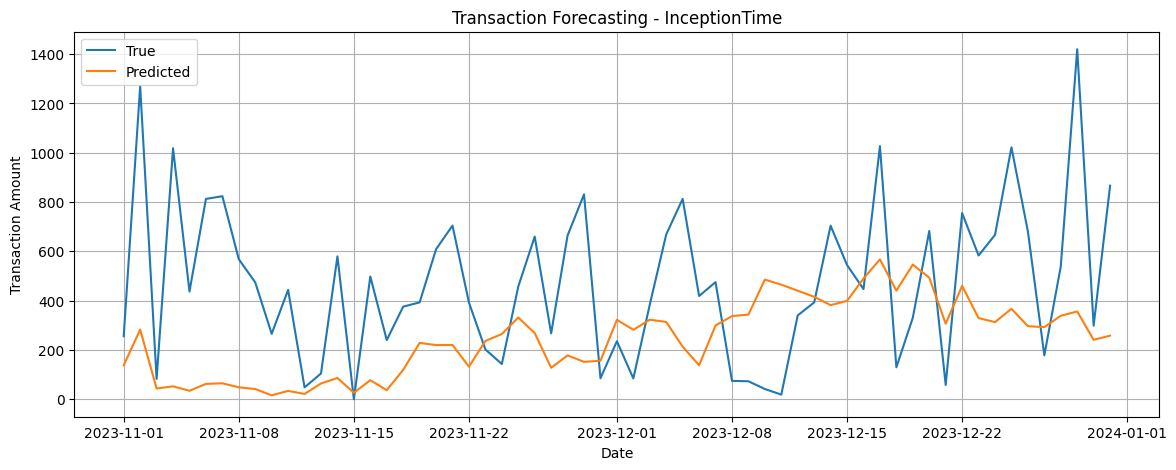

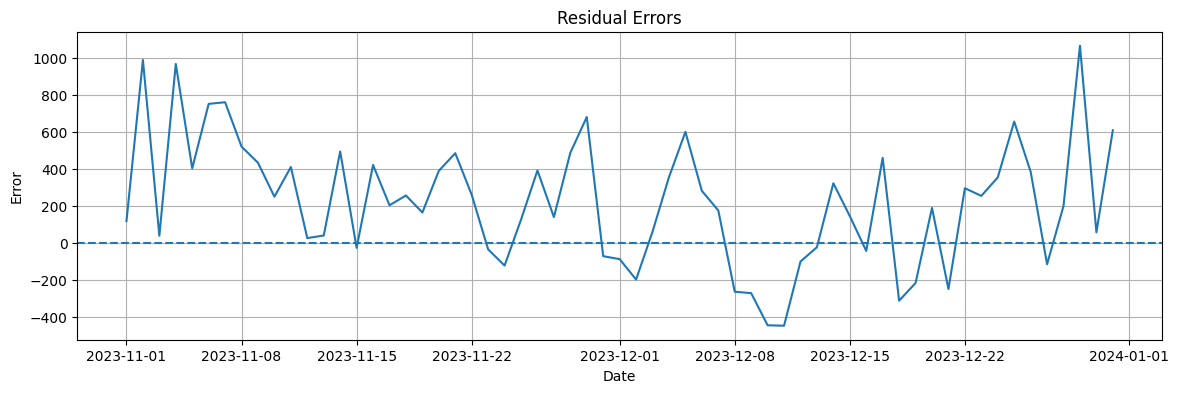

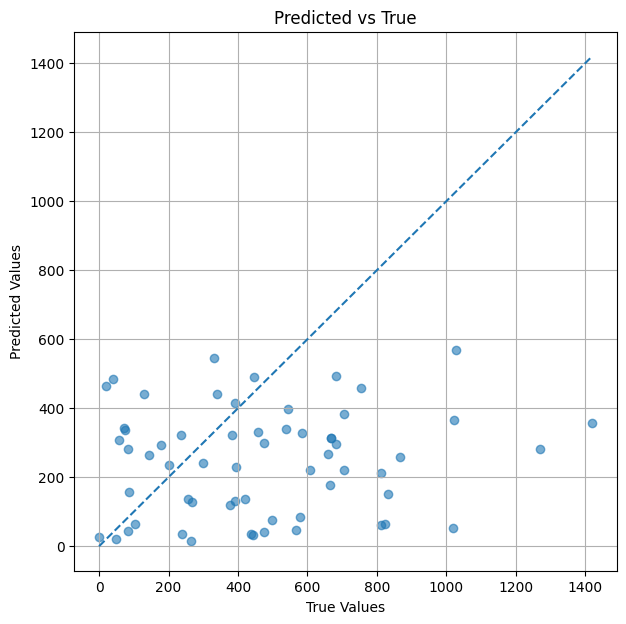

Better model found at epoch 0 with valid_loss value: 322.5516662597656.

MAE : 322.5517
RMSE: 405.2733


In [9]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

set_seed(42, reproducible=True)


df = pd.read_csv('dataset.csv')

df = df[df['User_ID'] != 'USER_0007'].copy()
df['Location'] = df['Location'].replace('Lndn', 'London')
df = df.loc[df['Transaction_Amount'] > 0, :].copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"])




daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])

daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)




values_raw = daily["Total_Transaction"].values.astype(np.float32)




window_size = 60

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    X.append(values_raw[i:i+window_size])

    y.append(values_raw[i+window_size])

    dates.append(daily["Date"].iloc[i+window_size])

X = np.array(X)
y = np.array(y)

dates = pd.to_datetime(dates)

# tsai expects:
# (samples, channels, timesteps)

X = X[:, np.newaxis, :]

print("X shape:", X.shape)
print("y shape:", y.shape)



split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)

print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))



dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=16
)



model = InceptionTime(
    c_in=1,
    c_out=1
)

print(model)




learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_inceptiontime_model'
    )
)




learn.fit_one_cycle(50, 1e-3)




preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()



test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets,
    label='True'
)

plt.plot(
    test_dates,
    preds,
    label='Predicted'
)

plt.title("Transaction Forecasting - InceptionTime")

plt.xlabel("Date")
plt.ylabel("Transaction Amount")

plt.legend()
plt.grid(True)

plt.show()




residuals = targets - preds

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(0, linestyle='--')

plt.title("Residual Errors")

plt.xlabel("Date")
plt.ylabel("Error")

plt.grid(True)

plt.show()




plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    preds,
    alpha=0.6
)

min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()



loss, mae_val, rmse_val = learn.validate()

print(f"\nMAE : {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")

## 2. Multivarijatni

A. bez skaliranja (raw)

X shape: (298, 11, 60)
y shape: (298,)
Train samples: 237
Test samples: 61
InceptionTime(
  (inceptionblock): InceptionBlock(
    (inception): ModuleList(
      (0): InceptionModule(
        (bottleneck): Conv1d(11, 32, kernel_size=(1,), stride=(1,), bias=False)
        (convs): ModuleList(
          (0): Conv1d(32, 32, kernel_size=(39,), stride=(1,), padding=(19,), bias=False)
          (1): Conv1d(32, 32, kernel_size=(19,), stride=(1,), padding=(9,), bias=False)
          (2): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
        )
        (maxconvpool): Sequential(
          (0): MaxPool1d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
          (1): Conv1d(11, 32, kernel_size=(1,), stride=(1,), bias=False)
        )
        (concat): Concat(dim=1)
        (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
      )
      (1-5): 5 x InceptionModule(
        (bottleneck): Conv1d(128, 3

epoch,train_loss,valid_loss,mae,_rmse,time
0,308964.312500,322172.250000,470.014404,567.602234,00:00
1,307863.656250,321938.281250,469.766693,567.396057,00:00
2,311350.812500,321547.781250,469.361969,567.051819,00:00
3,310107.656250,321193.437500,468.994232,566.739319,00:00
4,310161.812500,320730.812500,468.518463,566.331055,00:00
5,309202.531250,319065.875000,466.806885,564.859192,00:00
6,310302.187500,318727.125000,466.481598,564.559204,00:00
7,307422.437500,318591.156250,466.336517,564.438782,00:00
8,306748.687500,317558.625000,465.280609,563.523376,00:00
9,303660.125000,316707.562500,464.424194,562.767761,00:00


Better model found at epoch 0 with valid_loss value: 322172.25.
Better model found at epoch 1 with valid_loss value: 321938.28125.
Better model found at epoch 2 with valid_loss value: 321547.78125.
Better model found at epoch 3 with valid_loss value: 321193.4375.
Better model found at epoch 4 with valid_loss value: 320730.8125.
Better model found at epoch 5 with valid_loss value: 319065.875.
Better model found at epoch 6 with valid_loss value: 318727.125.
Better model found at epoch 7 with valid_loss value: 318591.15625.
Better model found at epoch 8 with valid_loss value: 317558.625.
Better model found at epoch 9 with valid_loss value: 316707.5625.
Better model found at epoch 12 with valid_loss value: 314230.21875.
Better model found at epoch 13 with valid_loss value: 308744.4375.
Better model found at epoch 14 with valid_loss value: 296369.125.
Better model found at epoch 16 with valid_loss value: 263707.65625.
Better model found at epoch 19 with valid_loss value: 253328.265625.
Bett

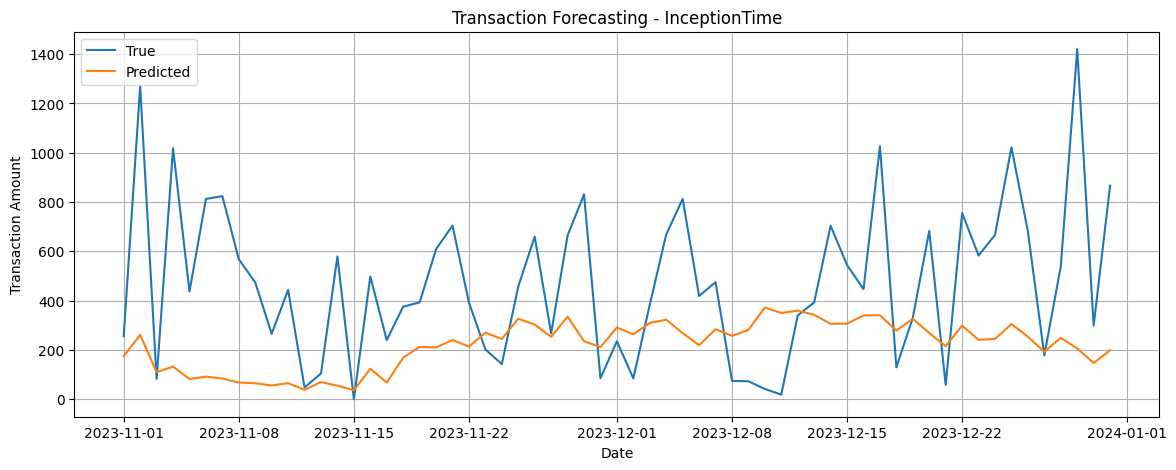

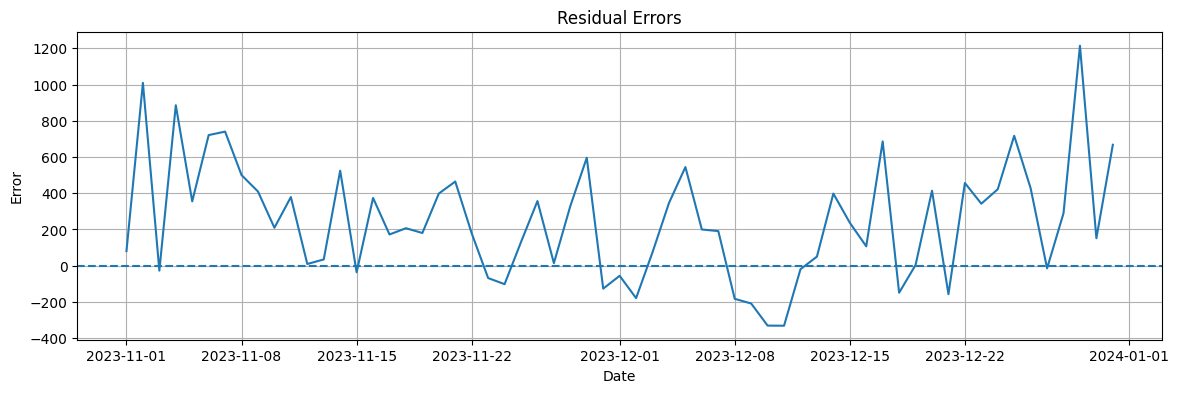

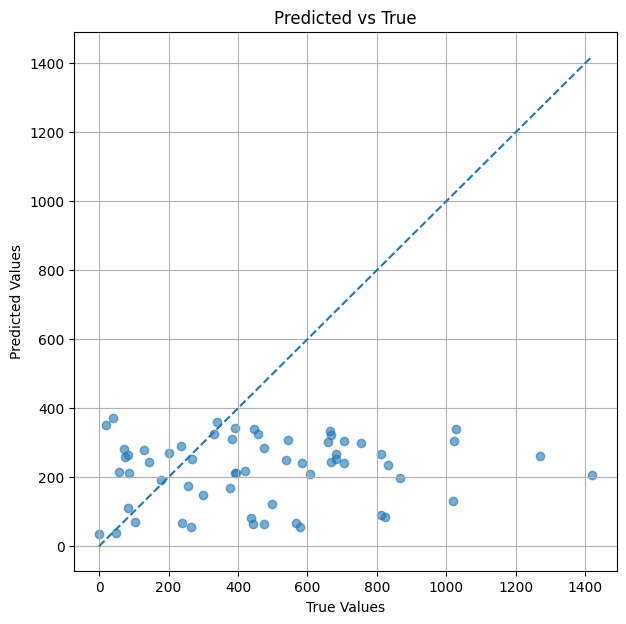

Better model found at epoch 0 with valid_loss value: 314.5998840332031.

MAE : 314.5999
RMSE: 407.9814


In [10]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

set_seed(42, reproducible=True)




df = pd.read_csv('dataset.csv')

df = df[df['User_ID'] != 'USER_0007'].copy()

df['Location'] = df['Location'].replace(
    'Lndn',
    'London'
)

df = df.loc[
    df['Transaction_Amount'] > 0,
    :
].copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"])




daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])

daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)


# =========================
# EXTRA FEATURES
# =========================

daily['dayofweek'] = daily['Date'].dt.dayofweek

daily['weekday_sin'] = np.sin(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['weekday_cos'] = np.cos(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['is_weekend'] = (
    daily['dayofweek'] >= 5
).astype(float)

daily['month'] = daily['Date'].dt.month

daily['month_sin'] = np.sin(
    2 * np.pi * daily['month'] / 12
)

daily['month_cos'] = np.cos(
    2 * np.pi * daily['month'] / 12
)

daily['rolling_mean_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .mean()
)

daily['rolling_std_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .std()
)

daily['lag_1'] = daily['Total_Transaction'].shift(1)

daily['lag_7'] = daily['Total_Transaction'].shift(7)

daily['expanding_mean'] = (
    daily['Total_Transaction']
    .shift(1)
    .expanding()
    .mean()
)

daily = daily.dropna().reset_index(drop=True)



values_raw = daily["Total_Transaction"].values

weekday_sin = daily["weekday_sin"].values
weekday_cos = daily["weekday_cos"].values

is_weekend = daily["is_weekend"].values

month_sin = daily["month_sin"].values
month_cos = daily["month_cos"].values

rolling_mean_7 = daily["rolling_mean_7"].values
rolling_std_7 = daily["rolling_std_7"].values

lag_1 = daily["lag_1"].values
lag_7 = daily["lag_7"].values

expanding_mean = daily["expanding_mean"].values




window_size = 60

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    signal_window = values_raw[i:i+window_size]

    sin_window = weekday_sin[i:i+window_size]
    cos_window = weekday_cos[i:i+window_size]

    weekend_window = is_weekend[i:i+window_size]

    month_sin_window = month_sin[i:i+window_size]
    month_cos_window = month_cos[i:i+window_size]

    rolling_mean_window = rolling_mean_7[i:i+window_size]
    rolling_std_window = rolling_std_7[i:i+window_size]

    lag1_window = lag_1[i:i+window_size]
    lag7_window = lag_7[i:i+window_size]

    expanding_mean_window = expanding_mean[i:i+window_size]

    sample = np.stack([

        signal_window,

        sin_window,
        cos_window,

        weekend_window,

        month_sin_window,
        month_cos_window,

        rolling_mean_window,
        rolling_std_window,

        lag1_window,
        lag7_window,

        expanding_mean_window

    ])

    X.append(sample)

    y.append(values_raw[i+window_size])

    dates.append(
        daily["Date"].iloc[i+window_size]
    )


X = np.array(X, dtype=np.float32)

y = np.array(y, dtype=np.float32)

dates = pd.to_datetime(dates)


print("X shape:", X.shape)
print("y shape:", y.shape)



split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]

test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)

print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))




dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=16
)


model = InceptionTime(
    c_in=11,
    c_out=1
)

print(model)




learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_inceptiontime_model'
    )
)



learn.fit_one_cycle(50, 1e-3)




preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()

targets = targets.squeeze().numpy()




test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets,
    label='True'
)

plt.plot(
    test_dates,
    preds,
    label='Predicted'
)

plt.title("Transaction Forecasting - InceptionTime")

plt.xlabel("Date")

plt.ylabel("Transaction Amount")

plt.legend()

plt.grid(True)

plt.show()




residuals = targets - preds

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title("Residual Errors")

plt.xlabel("Date")

plt.ylabel("Error")

plt.grid(True)

plt.show()




plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    preds,
    alpha=0.6
)

min_val = min(
    targets.min(),
    preds.min()
)

max_val = max(
    targets.max(),
    preds.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")

plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()



loss, mae_val, rmse_val = learn.validate()

print(f"\nMAE : {mae_val:.4f}")

print(f"RMSE: {rmse_val:.4f}")

### B. z-scale

X shape: (298, 11, 60)
y shape: (298,)
Train samples: 237
Test samples: 61
InceptionTime(
  (inceptionblock): InceptionBlock(
    (inception): ModuleList(
      (0): InceptionModule(
        (bottleneck): Conv1d(11, 32, kernel_size=(1,), stride=(1,), bias=False)
        (convs): ModuleList(
          (0): Conv1d(32, 32, kernel_size=(39,), stride=(1,), padding=(19,), bias=False)
          (1): Conv1d(32, 32, kernel_size=(19,), stride=(1,), padding=(9,), bias=False)
          (2): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
        )
        (maxconvpool): Sequential(
          (0): MaxPool1d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
          (1): Conv1d(11, 32, kernel_size=(1,), stride=(1,), bias=False)
        )
        (concat): Concat(dim=1)
        (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
      )
      (1-5): 5 x InceptionModule(
        (bottleneck): Conv1d(128, 3

epoch,train_loss,valid_loss,mae,_rmse,time
0,1.136145,1.196515,0.880830,1.093853,00:00
1,1.100924,1.201102,0.885476,1.095948,00:00
2,1.072093,1.197807,0.875280,1.094444,00:00
3,1.041539,1.230647,0.887913,1.109345,00:00
4,1.048315,2.647429,1.288966,1.627092,00:00
5,1.053724,1.248512,0.897856,1.117368,00:00
6,1.048167,1.229103,0.890405,1.108649,00:00
7,1.031878,1.442813,1.011309,1.201172,00:00
8,1.030249,1.236777,0.897914,1.112105,00:00
9,1.002985,1.273317,0.927749,1.128414,00:00


Better model found at epoch 0 with valid_loss value: 1.1965150833129883.


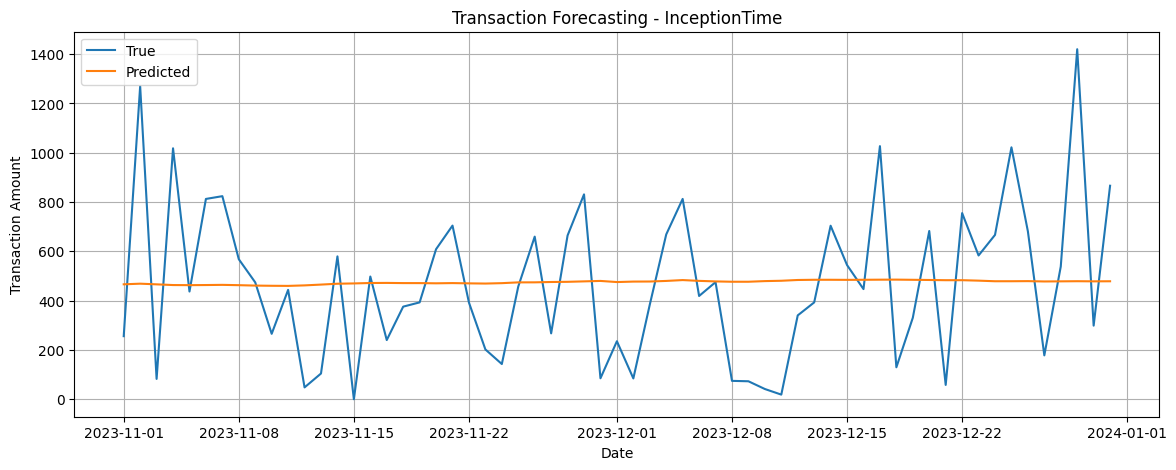

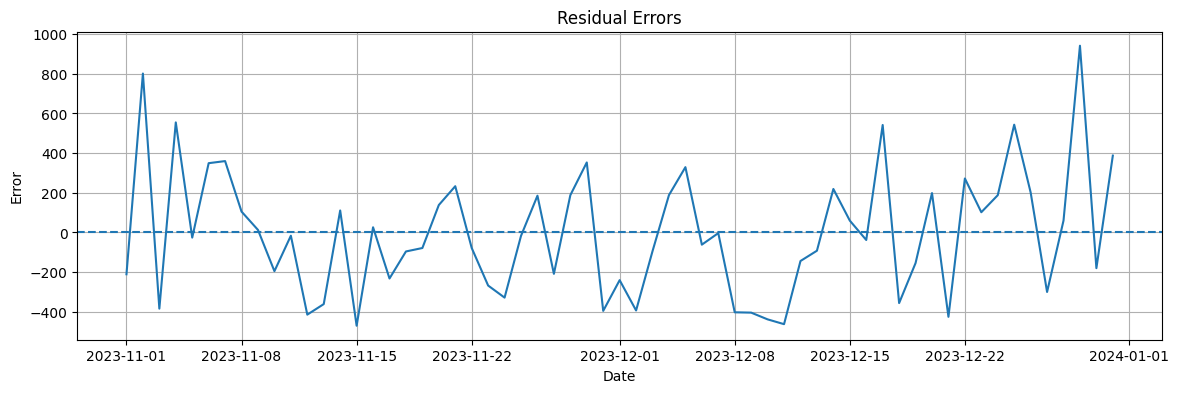

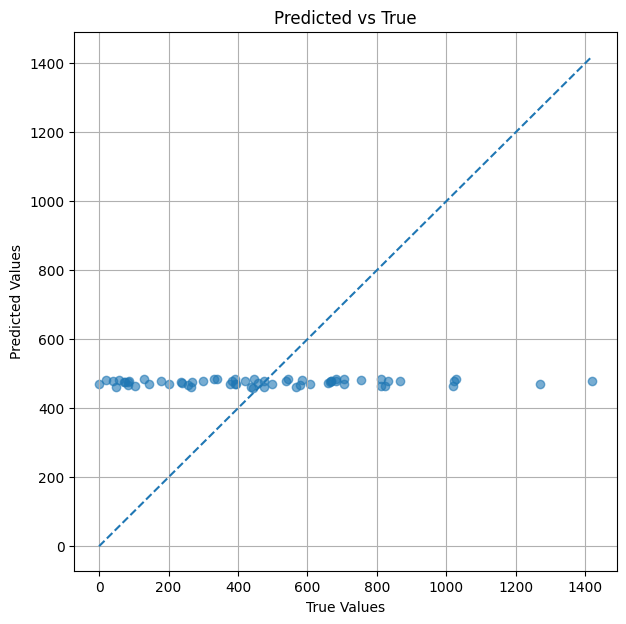


MAE : 255.96
RMSE: 317.87


In [11]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


set_seed(42, reproducible=True)


df = pd.read_csv('dataset.csv')

df = df[df['User_ID'] != 'USER_0007'].copy()
df['Location'] = df['Location'].replace('Lndn', 'London')
df = df.loc[df['Transaction_Amount'] > 0, :].copy()


df["Timestamp"] = pd.to_datetime(df["Timestamp"])


daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])


daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)


# FEATS

daily['dayofweek'] = daily['Date'].dt.dayofweek

daily['weekday_sin'] = np.sin(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['weekday_cos'] = np.cos(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['is_weekend'] = (
    daily['dayofweek'] >= 5
).astype(float)

daily['month'] = daily['Date'].dt.month

daily['month_sin'] = np.sin(
    2 * np.pi * daily['month'] / 12
)

daily['month_cos'] = np.cos(
    2 * np.pi * daily['month'] / 12
)

daily['rolling_mean_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .mean()
)

daily['rolling_std_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .std()
)

daily['lag_1'] = (
    daily['Total_Transaction']
    .shift(1)
)

daily['lag_7'] = (
    daily['Total_Transaction']
    .shift(7)
)

daily['expanding_mean'] = (
    daily['Total_Transaction']
    .shift(1)
    .expanding()
    .mean()
)

daily = daily.dropna().reset_index(drop=True)



split_date = pd.Timestamp('2023-11-01')

train_mask = (
    daily["Date"] < split_date
)

# ============================================
# NORMALIZATION
# ============================================

scale_cols = [
    "Total_Transaction",
    "rolling_mean_7",
    "rolling_std_7",
    "lag_1",
    "lag_7",
    "expanding_mean"
]

scaler = StandardScaler()

# FIT ONLY ON TRAIN

daily.loc[train_mask, scale_cols] = (
    scaler.fit_transform(
        daily.loc[train_mask, scale_cols]
    )
)

# TRANSFORM TEST

daily.loc[~train_mask, scale_cols] = (
    scaler.transform(
        daily.loc[~train_mask, scale_cols]
    )
)



values_raw = (
    daily["Total_Transaction"].values
)

weekday_sin = (
    daily["weekday_sin"].values
)

weekday_cos = (
    daily["weekday_cos"].values
)

is_weekend = (
    daily["is_weekend"].values
)

month_sin = (
    daily["month_sin"].values
)

month_cos = (
    daily["month_cos"].values
)

rolling_mean_7 = (
    daily["rolling_mean_7"].values
)

rolling_std_7 = (
    daily["rolling_std_7"].values
)

lag_1 = (
    daily["lag_1"].values
)

lag_7 = (
    daily["lag_7"].values
)

expanding_mean = (
    daily["expanding_mean"].values
)

daily = daily.dropna().reset_index(drop=True)



values_raw = daily["Total_Transaction"].values
weekday_sin = daily["weekday_sin"].values
weekday_cos = daily["weekday_cos"].values
is_weekend = daily["is_weekend"].values
month_sin = daily["month_sin"].values
month_cos = daily["month_cos"].values
rolling_mean_7 = daily["rolling_mean_7"].values
rolling_std_7 = daily["rolling_std_7"].values
lag_1 = daily["lag_1"].values
lag_7 = daily["lag_7"].values
expanding_mean = daily["expanding_mean"].values



# MULTICHANNEL WINDOWS
window_size = 60

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    signal_window = values_raw[i:i+window_size]

    sin_window = weekday_sin[i:i+window_size]

    cos_window = weekday_cos[i:i+window_size]

    weekend_window = is_weekend[i:i+window_size]

    month_sin_window = month_sin[i:i+window_size]

    month_cos_window = month_cos[i:i+window_size]
    rolling_mean_window = rolling_mean_7[i:i+window_size]

    rolling_std_window = rolling_std_7[i:i+window_size]
    lag1_window = lag_1[i:i+window_size]

    lag7_window = lag_7[i:i+window_size]
    expanding_mean_window = expanding_mean[i:i+window_size]

    sample = np.stack([
        signal_window,
        sin_window,
        cos_window,
        weekend_window,

        month_sin_window,
        month_cos_window,

        rolling_mean_window,
        rolling_std_window,

        lag1_window,
        lag7_window,
        expanding_mean_window

    ])

    X.append(sample)

    y.append(values_raw[i+window_size])

    dates.append(daily["Date"].iloc[i+window_size])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

dates = pd.to_datetime(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)



split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)



print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))



dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=16
)



model = InceptionTime(
    c_in=11,
    c_out=1
)

print(model)




learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_inceptiontime_model'
    )
)



learn.fit_one_cycle(30, 1e-3)




preds, targets = learn.get_preds()


# inverse transform target channel
target_mean = scaler.mean_[0]
target_std = scaler.scale_[0]

preds_real = (
    preds * target_std
    + target_mean
)

targets_real = (
    targets * target_std
    + target_mean
)

preds_real = preds_real.squeeze().numpy()

targets_real = targets_real.squeeze().numpy()




test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets_real,
    label='True'
)

plt.plot(
    test_dates,
    preds_real,
    label='Predicted'
)

plt.title("Transaction Forecasting - InceptionTime")

plt.xlabel("Date")

plt.ylabel("Transaction Amount")

plt.legend()

plt.grid(True)

plt.show()



residuals = (
    targets_real
    - preds_real
)

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title("Residual Errors")

plt.xlabel("Date")

plt.ylabel("Error")

plt.grid(True)

plt.show()



plt.figure(figsize=(7,7))

plt.scatter(
    targets_real,
    preds_real,
    alpha=0.6
)

min_val = min(
    targets_real.min(),
    preds_real.min()
)

max_val = max(
    targets_real.max(),
    preds_real.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")

plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()



from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae_real = mean_absolute_error(
    targets_real,
    preds_real
)

rmse_real = np.sqrt(
    mean_squared_error(
        targets_real,
        preds_real
    )
)

print(f"\nMAE : {mae_real:.2f}")

print(f"RMSE: {rmse_real:.2f}")

*Naučio je mean...*